# delmesher + PyVista: from a surface to a tetrahedral mesh

[`delmesher`](https://github.com/MarcoAttene/DelOptim) turns a triangulated
*surface* into a high-quality tetrahedral mesh of its *interior*, and is robust
to the inputs that defeat classical meshers — faces meeting at sharp/acute
angles and arbitrarily low-quality (even near-degenerate) triangulations.

It is the reference implementation of *Surface Chamfering for Robust Tetrahedral
Meshing* (Diazzi, Dai, Panozzo, Attene — SIGGRAPH 2026). The pipeline has three
stages, and this notebook visualizes the output of each one with
[PyVista](https://pyvista.org/):

1. **Chamfering** — the input surface is locally and minimally modified to
   remove the acute angles that obstruct robust meshing.
2. **Delaunay refinement** — the volume around the chamfered surface is
   tetrahedralized into well-shaped elements (min face angle > 14°).
3. **Enriched CDT** — exact conformance to the *original* input surface is
   restored, adding a few lower-quality tetrahedra only where strictly needed.

> **Requirements:** `pip install .` (the `delmesher` bindings) and
> `pip install pyvista`. Every keyword of `delmesher.tetrahedralize` maps to a
> command-line flag of the `delmesher` tool.

In [1]:
import warnings
import numpy as np
from pathlib import Path
import pyvista as pv
import delmesher

# Static images render inline and on GitHub; switch to "trame" for interactive
# 3D (rotate/zoom) when running this notebook live in Jupyter.
pv.set_jupyter_backend("static")

print("delmesher", delmesher.__version__, "| pyvista", pv.__version__)

delmesher 1.0.0 | pyvista 0.48.4


## Helpers: NumPy arrays → PyVista meshes

`delmesher` speaks NumPy: surfaces are `(n, 3)` vertices + `(m, 3)` triangle
indices, and volume meshes are `(n, 3)` vertices + `(k, 4)` tetrahedron indices.
The helpers below wrap those arrays into PyVista objects and provide an interior
view of a volume mesh: keeping only the tetrahedra inside a given boundary
surface (delmesher meshes a bounding box around the input) and clipping the
result in half so the interior tetrahedra — and their faces — are visible.

In [2]:
# (V,3) vertices + (F,3) triangle indices  ->  pv.PolyData
def to_surface(vertices, faces):
    faces = np.asarray(faces, np.int64)
    cells = np.empty((len(faces), 4), np.int64)
    cells[:, 0] = 3          # 3 vertices per face
    cells[:, 1:] = faces
    return pv.PolyData(np.asarray(vertices, float), cells.ravel())


# (V,3) vertices + (T,4) tetrahedron indices  ->  pv.UnstructuredGrid
def to_tetmesh(vertices, tets):
    tets = np.asarray(tets, np.int64)
    cells = np.empty((len(tets), 5), np.int64)
    cells[:, 0] = 4          # 4 vertices per tetrahedron
    cells[:, 1:] = tets
    celltypes = np.full(len(tets), pv.CellType.TETRA, np.uint8)
    return pv.UnstructuredGrid(cells.ravel(), celltypes, np.asarray(vertices, float))


def show_surface(mesh, color, title=None):
    p = pv.Plotter(window_size=(760, 520))
    p.add_mesh(mesh, color=color, show_edges=True, edge_color="gray", line_width=1)
    if title:
        p.add_text(title, font_size=11)
    p.show()


# delmesher tetrahedralizes a bounding box around the input, so most tets lie
# OUTSIDE the part. Keep only those whose centre is inside the closed boundary
# surface, so we visualize the mesh of the object itself.
def interior_cells(grid, boundary):
    centers = grid.cell_centers()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # select_enclosed_points name varies by version
        if hasattr(centers, "select_interior_points"):
            sel = centers.select_interior_points(boundary, check_surface=False)
            mask = sel["selected_points"].astype(bool)
        else:
            sel = centers.select_enclosed_points(boundary, check_surface=False)
            mask = sel["SelectedPoints"].astype(bool)
    return grid.extract_cells(mask)


# Show only the interior tetrahedra, clipped in half by a plane. crinkle=True
# keeps whole tetrahedra (rather than slicing through them), so the cut exposes
# the interior triangular faces of the tets along the section.
def show_interior(grid, boundary, color, title=None, axis="x"):
    inside = interior_cells(grid, boundary)
    half = inside.clip(axis, crinkle=True)
    p = pv.Plotter(window_size=(760, 520))
    p.add_mesh(half, color=color, show_edges=True, edge_color="gray", line_width=1)
    p.view_isometric()
    if title:
        p.add_text(title, font_size=11)
    p.show()

## 1. Load the test mesh

`input_models/boeing_part.off` is the model shipped with the repository: a
mechanical part whose faces meet at acute angles and carry a low-quality
triangulation — exactly the kind of input this method is built for. We read it
straight into NumPy arrays with `delmesher.read_off`.

In [3]:
def find_model():
    for base in [Path.cwd(), *Path.cwd().parents]:
        cand = base / "input_models" / "boeing_part.off"
        if cand.exists():
            return cand
    raise FileNotFoundError("boeing_part.off not found; run from the repo")

model = find_model()
vertices, triangles = delmesher.read_off(model)
print(f"{model.name}: {len(vertices)} vertices, {len(triangles)} triangles")

boeing_part.off: 3406 vertices, 6848 triangles


## 2. Visualize the input surface

The input may be an open or closed surface; it only needs to be free of
degenerate or self-intersecting triangles (duplicate vertices/triangles are
cleaned up automatically). This is the surface we will fill with tetrahedra.

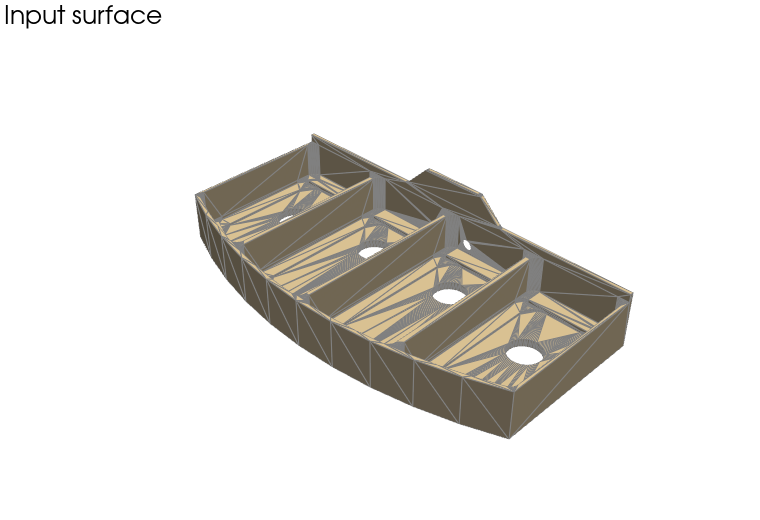

In [4]:
show_surface(to_surface(vertices, triangles), "wheat", "Input surface")

## 3. Create the tetrahedral mesh

A single call runs the whole pipeline. Each keyword mirrors a CLI flag:

| keyword | CLI | meaning |
| --- | --- | --- |
| `enriched_cdt=True` | (default) | run the final enriched-CDT phase; `False` (`-a`) stops after Delaunay refinement |
| `max_vertices=N` | `-m` | stop refinement after `N` inserted vertices |
| `sliver_removal` | `-d` | remove sliver tetrahedra during refinement |
| `lfs_exponent` | `-e` | ignore tiny features below `10⁻ᵉ × bbox diagonal` |
| `compute_lfs` | `-c` | report the input's minimum local feature size |
| `verbose` | `-v` | print progress |

Here we let Delaunay refinement run all the way to convergence (no
`max_vertices` cap), so this call can take several minutes. Pass
`max_vertices=N` if you would rather stop early for a quick preview.

In [5]:
result = delmesher.tetrahedralize(
    vertices, triangles, compute_lfs=True
)

print("input is manifold       :", result.input_is_manifold)
print("input encloses a volume :", result.input_has_interior)
print("min LFS / bbox diagonal :", result.min_lfs)
print("Delaunay-refined mesh   :",
      result.dr_vertices.shape[0], "verts,",
      result.dr_tetrahedra.shape[0], "tets")
print("enriched CDT mesh       :",
      result.cdt_vertices.shape[0], "verts,",
      result.cdt_tetrahedra.shape[0], "tets")

input is manifold       : True
input encloses a volume : True
min LFS / bbox diagonal : 1.1620470559835108e-05
Delaunay-refined mesh   : 90665 verts, 550595 tets
enriched CDT mesh       : 83051 verts, 497587 tets


## 4. The outputs of each pipeline stage

`result` exposes every mesh the command-line tool can write, as NumPy arrays.
We visualize them below in pipeline order, each with a short description.

### 4a. Chamfered surface &nbsp;·&nbsp; `result.chamfered_*` &nbsp;·&nbsp; CLI `-u`

The first stage **chamfers** the input: it locally and minimally cuts away the
acute dihedral/planar angles between faces — the main obstacle to robust,
well-shaped meshing — replacing each sharp corner with a small bevel. Every
chamfered facet still lies within one original input triangle. This chamfered
surface is what the Delaunay refinement actually meshes.

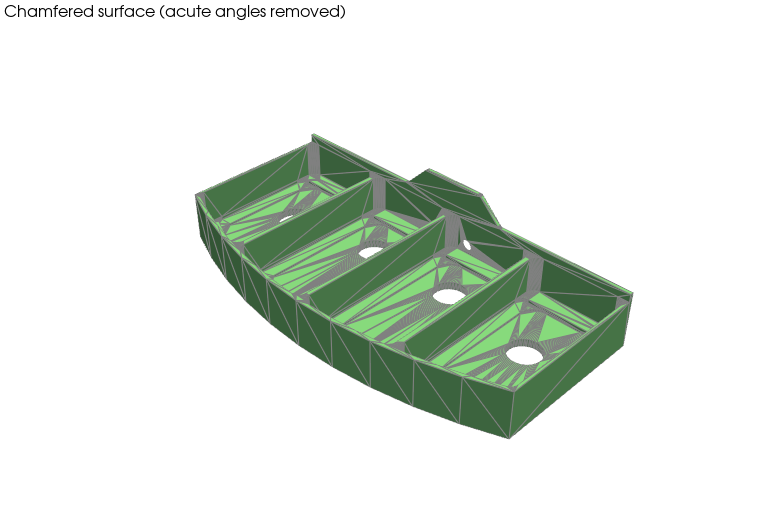

In [6]:
show_surface(to_surface(result.chamfered_vertices, result.chamfered_faces),
             "palegreen", "Chamfered surface (acute angles removed)")

### 4b. Delaunay-refinement interface &nbsp;·&nbsp; `result.dr_interface_*` &nbsp;·&nbsp; CLI `-w`

The Delaunay refinement tetrahedralizes a bounding box around the chamfered
surface and classifies each tetrahedron as interior or exterior. This surface is
the **interface** between the two — i.e. the outer boundary of the well-shaped
volume mesh. It closely follows the chamfered input.

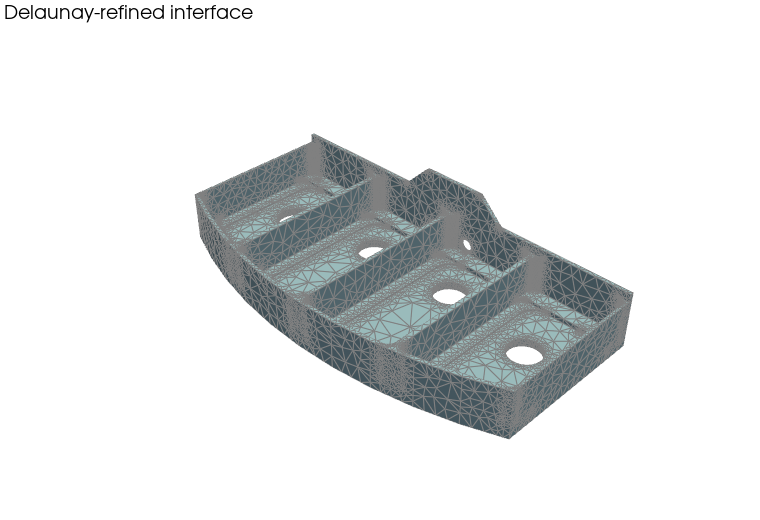

In [7]:
show_surface(to_surface(result.dr_interface_vertices, result.dr_interface_faces),
             "lightblue", "Delaunay-refined interface")

### 4c. Delaunay-refined tetrahedral mesh &nbsp;·&nbsp; `result.dr_*` &nbsp;·&nbsp; CLI `-x`

The angle-bounded volume mesh itself: well-shaped tetrahedra with a guaranteed
lower bound on their face angles (> 14°). delmesher tetrahedralizes the whole
bounding box, so we keep only the tetrahedra **inside** the `dr_interface`
boundary and clip the result in half — keeping whole tetrahedra, so the cut
exposes their interior triangular faces. At this stage the constrained faces are
**not yet conformal** to the *original* input surface — that is what the next
stage fixes.

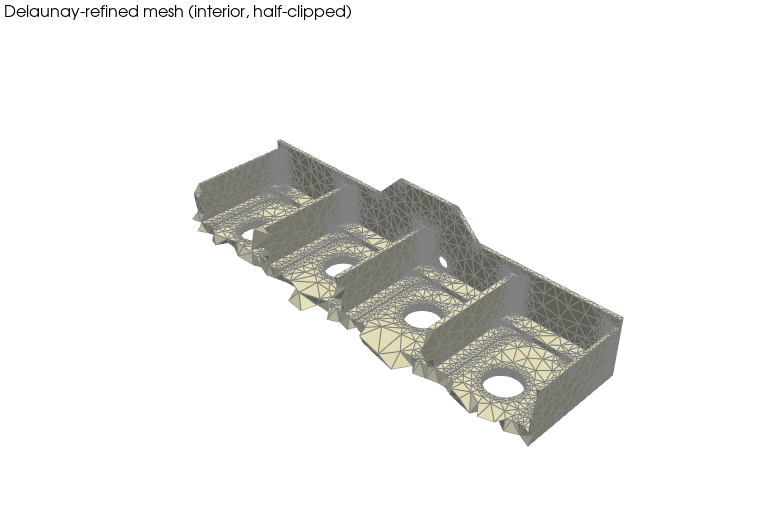

In [8]:
show_interior(to_tetmesh(result.dr_vertices, result.dr_tetrahedra),
              to_surface(result.dr_interface_vertices, result.dr_interface_faces),
              "lightyellow", "Delaunay-refined mesh (interior, half-clipped)")

### 4d. Enriched CDT — the final mesh &nbsp;·&nbsp; `result.cdt_*` &nbsp;·&nbsp; CLI `-z`

The final stage restores **exact conformance to the original input surface**,
introducing a few lower-quality tetrahedra only where strictly necessary. This
is the production output: a tetrahedral mesh that both is well-shaped almost
everywhere and reproduces the input geometry exactly. Here we keep the
tetrahedra enclosed by the *original input surface* (which the enriched CDT
reproduces exactly) and clip it in half to reveal the interior tetrahedra and
their exposed faces.

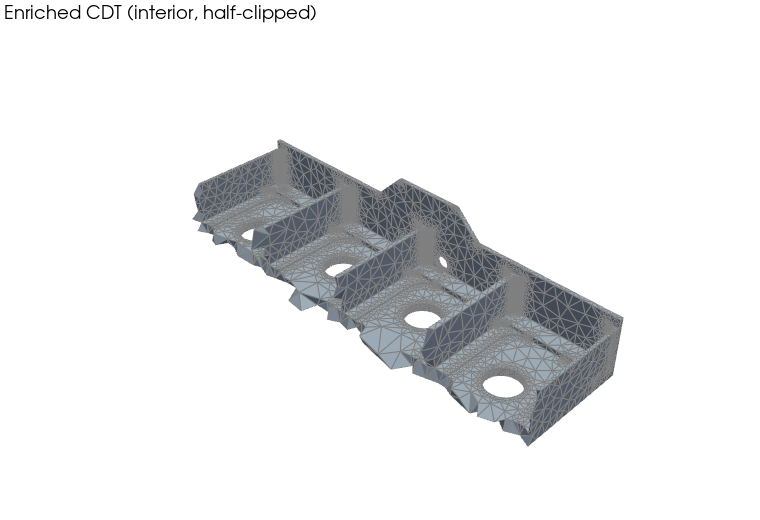

In [9]:
show_interior(to_tetmesh(result.cdt_vertices, result.cdt_tetrahedra),
              to_surface(vertices, triangles),
              "lightsteelblue", "Enriched CDT (interior, half-clipped)")

### Primary output

For convenience `result.vertices` / `result.tetrahedra` alias the **final**
mesh: the enriched CDT when it is computed (the default), or the
Delaunay-refined mesh when `enriched_cdt=False`. Save it with
`delmesher.write_tet(...)`.

In [10]:
print("primary output is the enriched CDT:",
      np.array_equal(result.vertices, result.cdt_vertices))
# delmesher.write_tet("out_mesh.tet", result.vertices, result.tetrahedra)

primary output is the enriched CDT: True
